# 03 - Annotation development set

This notebook manages the human-annotation set: the set of MathDial dialogues
labelled turn-by-turn against the misconception codebook. It does three things.

1. **Replicate the pipeline** that built the original set (formerly the
   *validation* set, now renamed the **development set**), loading it by its
   pinned dialogue ids so it is reproduced exactly rather than re-sampled.
2. **Profile family coverage** with a histogram across the six misconception
   families, for both the full development set and its labelled subset.
3. **Supplement by family** with a seeded, family-stratified draw from the
   untouched pool, so every family has enough examples, appended additively
   without disturbing any existing dialogue or label.

## Why load by pinned ids, not re-sample

A seeded draw only reproduces a set if the pool it draws from is identical.
Filtering, reordering, or a changed source all shift the pool, so the same seed
then selects different dialogues. The development set is therefore defined by its
saved dialogue ids, and this notebook loads those ids rather than regenerating
them. Supplementation is additive: it draws new ids from the pool, excludes every
existing id, and appends unlabelled rows, so the existing set is never altered.


## Setup

In [1]:
import os
from pathlib import Path

# Walk up to the repo root (folder containing data/annotated).
_here = Path.cwd()
for _c in [_here, *_here.parents]:
    if (_c / "data" / "annotated").exists():
        os.chdir(_c)
        break
else:
    raise FileNotFoundError("Could not find data/annotated above " + str(_here))

import json
from ast import literal_eval
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA = Path("data/annotated")
DEV_CSV = Path("extension/artifacts/development_set_legacy.csv")  # the preserved original set (read-only here)
DEV_OUT = Path("extension/artifacts/development_set.csv")         # the new supplemented set is written here
print("working directory:", os.getcwd())


working directory: /Users/tandon.utsav2/Desktop/Experiment_1


## The six misconception families

The student profile collapses to six families. This mapping is the single source
of truth for family membership throughout the notebook.


In [2]:
FAMILIES = {
    "A comprehension":   "what the problem is asking",
    "B principles":      "underlying ideas",
    "C relevance":       "relevant",           # 'relevant versus irrelevant'
    "D wrong-operation": "correct order",       # 'correct order / correct operation'
    "E steps":           "steps or procedures",
    "F problem-type":    "problem type",
}

def family_of(profile: str) -> str:
    t = str(profile).lower()
    if "what the problem is asking" in t: return "A comprehension"
    if "underlying ideas" in t or "principles" in t: return "B principles"
    if "relevant" in t and "irrelevant" in t: return "C relevance"
    if "correct order" in t or "correct operation" in t: return "D wrong-operation"
    if "steps or procedures" in t: return "E steps"
    if "problem type" in t: return "F problem-type"
    return "other"

FAMILY_ORDER = list(FAMILIES.keys())
print("families:", FAMILY_ORDER)


families: ['A comprehension', 'B principles', 'C relevance', 'D wrong-operation', 'E steps', 'F problem-type']


## Part 1: load the development set by its pinned ids

The development set is loaded from `development_set.csv`. Its dialogue ids are
the definition of the set; they are extracted here and treated as fixed. The
labelled subset (dialogues with at least one turn label) is identified so
coverage can be profiled for both.


In [3]:
dev = pd.read_csv(DEV_CSV, keep_default_na=False)

# Pinned ids: the definition of the development set.
dev_ids = sorted(dev["dialogue_id"].unique().tolist())
dev_dialogues = dev.drop_duplicates("dialogue_id")[["dialogue_id", "misconception_general"]].copy()
dev_dialogues["family"] = dev_dialogues["misconception_general"].apply(family_of)

# Labelled subset.
labelled_ids = sorted(dev.loc[dev["label"].str.strip() != "", "dialogue_id"].unique().tolist())
n_labelled_turns = int((dev["label"].str.strip() != "").sum())

print(f"development set: {len(dev_ids)} dialogues, {len(dev)} turns")
print(f"labelled: {len(labelled_ids)} dialogues, {n_labelled_turns} turns")
print(f"pinned ids: {dev_ids}")


development set: 55 dialogues, 308 turns
labelled: 0 dialogues, 0 turns
pinned ids: [37, 44, 96, 98, 188, 191, 319, 328, 523, 609, 680, 746, 748, 806, 887, 907, 927, 929, 977, 990, 1036, 1050, 1075, 1090, 1095, 1159, 1269, 1334, 1395, 1412, 1462, 1471, 1493, 1598, 1626, 1654, 1709, 1744, 1745, 1825, 1827, 1862, 1900, 1903, 1926, 1966, 1969, 2057, 2075, 2087, 2142, 2152, 2223, 2226, 2249]


## Part 2: family coverage histogram

The histogram shows how many dialogues each family contributes, for the full
development set and for its labelled subset. Uneven coverage here is what the
supplementation step corrects.


full development set, dialogues per family:
family
A comprehension       9
B principles         11
C relevance           5
D wrong-operation     9
E steps              13
F problem-type        8

labelled subset, dialogues per family:
family
A comprehension      0
B principles         0
C relevance          0
D wrong-operation    0
E steps              0
F problem-type       0


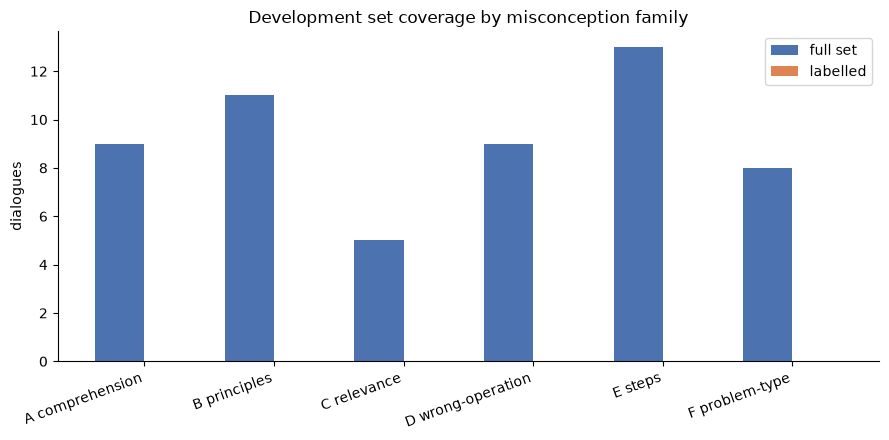

In [4]:
full_counts = (dev_dialogues["family"].value_counts()
                .reindex(FAMILY_ORDER, fill_value=0))
lab_counts = (dev_dialogues[dev_dialogues["dialogue_id"].isin(labelled_ids)]["family"]
              .value_counts().reindex(FAMILY_ORDER, fill_value=0))

print("full development set, dialogues per family:")
print(full_counts.to_string())
print("\nlabelled subset, dialogues per family:")
print(lab_counts.to_string())

x = np.arange(len(FAMILY_ORDER)); w = 0.38
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(x - w/2, full_counts.values, w, label="full set", color="#4C72B0")
ax.bar(x + w/2, lab_counts.values, w, label="labelled", color="#DD8452")
ax.set_xticks(x); ax.set_xticklabels(FAMILY_ORDER, rotation=20, ha="right")
ax.set_ylabel("dialogues"); ax.set_title("Development set coverage by misconception family")
ax.legend(); ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()


## Part 3: supplement under-represented families

To ensure enough examples per family, each family is topped up to a common
target number of dialogues by drawing from the untouched pool. The draw is
seeded and family-stratified, excludes every id already in the development set,
and (optionally) excludes a sealed held-out set so the two never overlap. Only
the shortfall is drawn: a family already at or above target adds nothing.


In [5]:
# Target dialogues per family (raise until every family is covered enough).
TARGET_PER_FAMILY = 13
SEED = 11
HELDOUT_IDS_PATH = None   # e.g. Path("heldout_ids.json") to also exclude a sealed set

# Load the full annotated source to draw new dialogues from.
CONV = {c: literal_eval for c in ["annotation"]}
src = pd.read_csv(DATA / "mathdial_train_atc.csv", converters=CONV)
ID_COL = "index" if "index" in src.columns else src.columns[0]
src["family"] = src["student_profile"].apply(family_of)

exclude = set(dev_ids)
if HELDOUT_IDS_PATH and Path(HELDOUT_IDS_PATH).exists():
    exclude |= set(json.load(open(HELDOUT_IDS_PATH)))

available = src[~src[ID_COL].isin(exclude)]
rng = np.random.default_rng(SEED)

chosen = []
print(f"target {TARGET_PER_FAMILY} dialogues per family (seed {SEED})\n")
for fam in FAMILY_ORDER:
    have = int(full_counts[fam])
    need = max(0, TARGET_PER_FAMILY - have)
    pool = available[available["family"] == fam][ID_COL].tolist()
    k = min(need, len(pool))
    picks = rng.choice(pool, size=k, replace=False).tolist() if k else []
    chosen.extend(int(p) for p in picks)
    print(f"  {fam:18s} have {have:2d}  need {need:2d}  pool {len(pool):3d}  drawing {k:2d}")

chosen = sorted(set(chosen))
print(f"\ntotal new dialogues to add: {len(chosen)}")
print("new ids:", chosen)


target 13 dialogues per family (seed 11)

  A comprehension    have  9  need  4  pool 404  drawing  4
  B principles       have 11  need  2  pool 374  drawing  2
  C relevance        have  5  need  8  pool 324  drawing  8
  D wrong-operation  have  9  need  4  pool 379  drawing  4
  E steps            have 13  need  0  pool 357  drawing  0
  F problem-type     have  8  need  5  pool 360  drawing  5

total new dialogues to add: 23
new ids: [59, 163, 280, 308, 329, 547, 634, 852, 1035, 1064, 1143, 1202, 1219, 1420, 1538, 1639, 1830, 1967, 2063, 2090, 2150, 2233, 2236]


### Build the supplemented rows and verify additivity

New dialogues are expanded to the same per-turn schema as the development set,
with empty `label` and `note` so they are ready for annotation. Before writing,
the notebook asserts that every existing row and label is unchanged: the
supplementation is strictly additive.


In [6]:
COLUMNS = list(dev.columns)

def _history_up_to(dialogue, turn_n):
    lines = []
    for e in dialogue:
        t = e.get("turn")
        teacher = (e.get("teacher") or "").strip()
        student = (e.get("student") or "").strip()
        if teacher: lines.append(f"Tutor: {teacher}")
        if t == turn_n: break
        if student: lines.append(f"Student (turn {t}): {student}")
    return "\n".join(lines)

def build_rows(ids):
    rows = []
    by_id = src.set_index(ID_COL)
    for did in ids:
        r = by_id.loc[did]
        profile = str(r["student_profile"]).strip()
        described = str(r.get("teacher_described_confusion", "")).strip()
        problem = str(r["question"]).strip()
        incorrect = str(r.get("student_incorrect_solution", "")).strip()
        dialogue = r["dialogue"]
        if isinstance(dialogue, str):
            dialogue = literal_eval(dialogue)
        for e in dialogue:
            t = e.get("turn")
            if t is None: continue
            rows.append({
                "dialogue_id": int(did), "turn": f"turn {t}",
                "misconception_general": profile, "misconception_specific": described,
                "problem": problem, "student_incorrect_solution": incorrect,
                "dialogue_history": _history_up_to(dialogue, t),
                "student_turn_text": (e.get("student") or "").strip(),
                "correct": "", "kcs": "", "label": "", "note": "",
            })
    return pd.DataFrame(rows, columns=COLUMNS)

new_rows = build_rows(chosen)
combined = pd.concat([dev, new_rows], ignore_index=True)

# Additivity guarantees.
assert combined.iloc[:len(dev)].equals(dev), "existing rows changed!"
assert (combined.iloc[:len(dev)]["label"].str.strip() != "").sum() == n_labelled_turns
print(f"additive check passed: {len(dev)} existing rows unchanged, "
      f"{len(new_rows)} new rows appended")
print(f"supplemented set: {combined['dialogue_id'].nunique()} dialogues, {len(combined)} turns")


additive check passed: 308 existing rows unchanged, 130 new rows appended
supplemented set: 78 dialogues, 438 turns


### Post-supplementation coverage

The histogram after supplementation should show every family at (or near) the
target. Families whose pool was smaller than the shortfall will fall short, which
is reported rather than forced.


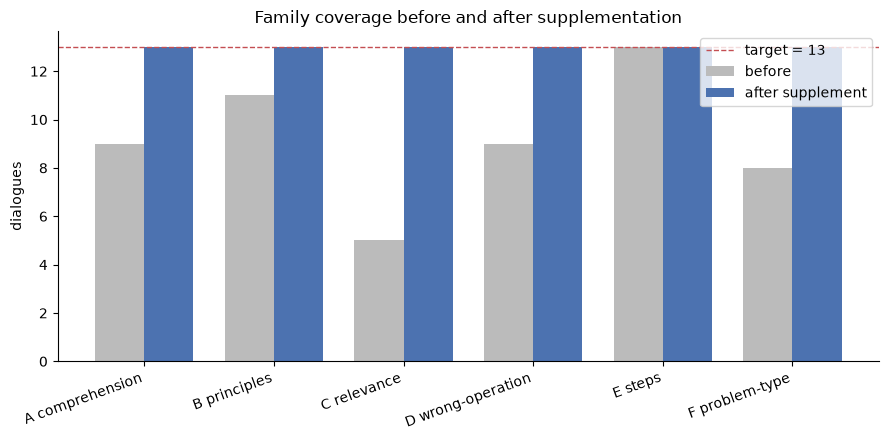

dialogues per family after supplementation:
family
A comprehension      13
B principles         13
C relevance          13
D wrong-operation    13
E steps              13
F problem-type       13


In [7]:
new_dialogues = combined.drop_duplicates("dialogue_id")[["dialogue_id", "misconception_general"]].copy()
new_dialogues["family"] = new_dialogues["misconception_general"].apply(family_of)
after_counts = new_dialogues["family"].value_counts().reindex(FAMILY_ORDER, fill_value=0)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(x - w/2, full_counts.values, w, label="before", color="#BBBBBB")
ax.bar(x + w/2, after_counts.values, w, label="after supplement", color="#4C72B0")
ax.axhline(TARGET_PER_FAMILY, ls="--", lw=1, color="#C44E52", label=f"target = {TARGET_PER_FAMILY}")
ax.set_xticks(x); ax.set_xticklabels(FAMILY_ORDER, rotation=20, ha="right")
ax.set_ylabel("dialogues"); ax.set_title("Family coverage before and after supplementation")
ax.legend(); ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

print("dialogues per family after supplementation:")
print(after_counts.to_string())


### Save the supplemented development set

Writing is guarded so the existing set is never overwritten by accident. Set
`WRITE = True` to persist. The new set is written alongside a pinned id list, so
it is reproducible by id and never depends on re-running the seeded draw.


In [8]:
WRITE = True

if WRITE:
    combined.to_csv(DEV_OUT, index=False)
    ids_out = sorted(combined["dialogue_id"].unique().tolist())
    json.dump({"seed": SEED, "target_per_family": TARGET_PER_FAMILY,
               "dialogue_ids": ids_out},
              open("extension/artifacts/development_set_ids.json", "w"), indent=2)
    print(f"written {DEV_OUT} ({len(combined)} rows) and development_set_ids.json "
          f"({len(ids_out)} ids)")
else:
    print("dry run: nothing written. Set WRITE = True to persist.")


written extension/artifacts/development_set.csv (438 rows) and development_set_ids.json (78 ids)


## Part 4: draw the validation set

The validation set is used to test how well LLMs annotate dialogues: an LLM
annotates these dialogues under the codebook, and its labels are compared against
a human gold standard. It is drawn fresh from the untouched pool, family-balanced
at the same target per family as the development set, and it **excludes every
development-set dialogue** so no dialogue is used both to build the codebook and
to evaluate the LLM.

The exclusion is taken against the *current* development set (original plus any
supplement), read from its pinned id list where available, so the two sets can
never overlap regardless of how the development set was supplemented.


In [9]:
# Validation target: equal dialogues per family, same as the development set.
VAL_TARGET_PER_FAMILY = 13
VAL_SEED = 23   # distinct from the development seed

# Exclusion set = every dialogue in the current development set.
# Prefer the pinned id file (reflects the supplemented set); fall back to the
# in-memory `combined` ids, then to the loaded `dev` ids.
DEV_IDS_PATH = Path("extension/artifacts/development_set_ids.json")
if DEV_IDS_PATH.exists():
    dev_id_set = set(json.load(open(DEV_IDS_PATH))["dialogue_ids"])
    src_of_ids = "pinned id file"
elif "combined" in dir():
    dev_id_set = set(int(i) for i in combined["dialogue_id"].unique())
    src_of_ids = "in-memory supplemented set"
else:
    dev_id_set = set(dev_ids)
    src_of_ids = "loaded development set"
print(f"excluding {len(dev_id_set)} development dialogues (from {src_of_ids})")

# Family-stratified draw from the pool, excluding all development ids.
val_available = src[~src[ID_COL].isin(dev_id_set)]
val_rng = np.random.default_rng(VAL_SEED)

val_chosen = []
print(f"\nvalidation target {VAL_TARGET_PER_FAMILY} dialogues per family (seed {VAL_SEED})")
for fam in FAMILY_ORDER:
    pool = val_available[val_available["family"] == fam][ID_COL].tolist()
    k = min(VAL_TARGET_PER_FAMILY, len(pool))
    picks = val_rng.choice(pool, size=k, replace=False).tolist() if k else []
    val_chosen.extend(int(p) for p in picks)
    print(f"  {fam:18s} pool {len(pool):3d}  drawing {k:2d}")

val_chosen = sorted(set(val_chosen))
print(f"\nvalidation dialogues: {len(val_chosen)}")

# No-overlap guarantee (asserted, not assumed).
overlap = set(val_chosen) & dev_id_set
assert not overlap, f"validation overlaps development: {sorted(overlap)}"
print(f"no-overlap check passed: 0 dialogues shared with the development set")


excluding 78 development dialogues (from pinned id file)

validation target 13 dialogues per family (seed 23)
  A comprehension    pool 400  drawing 13
  B principles       pool 372  drawing 13
  C relevance        pool 316  drawing 13
  D wrong-operation  pool 375  drawing 13
  E steps            pool 357  drawing 13
  F problem-type     pool 355  drawing 13

validation dialogues: 78
no-overlap check passed: 0 dialogues shared with the development set


### Build and save the validation set

The validation dialogues are expanded to the same annotation schema (empty
`label`/`note`, ready for the human gold standard and for the LLM to annotate
independently). Writing is guarded by `WRITE_VAL`; the set is saved with its own
pinned id list.


In [11]:
val_rows = build_rows(val_chosen)   # reuse the same row builder as the development set
print(f"validation set: {val_rows['dialogue_id'].nunique()} dialogues, {len(val_rows)} turns")

# Coverage check: equal per family.
_vc = val_rows.drop_duplicates("dialogue_id")["misconception_general"].apply(family_of)
print("validation dialogues per family:")
print(_vc.value_counts().reindex(FAMILY_ORDER, fill_value=0).to_string())

WRITE_VAL = True
VAL_OUT = Path("extension/artifacts/validation_set.csv")

if WRITE_VAL:
    val_rows.to_csv(VAL_OUT, index=False)
    json.dump({"seed": VAL_SEED, "target_per_family": VAL_TARGET_PER_FAMILY,
               "dialogue_ids": val_chosen,
               "excludes_development_ids": sorted(dev_id_set)},
              open("extension/artifacts/validation_set_ids.json", "w"), indent=2)
    print(f"\nwritten {VAL_OUT} ({len(val_rows)} rows) and validation_set_ids.json "
          f"({len(val_chosen)} ids)")
else:
    print("\ndry run: nothing written. Set WRITE_VAL = True to persist.")


validation set: 78 dialogues, 466 turns
validation dialogues per family:
misconception_general
A comprehension      13
B principles         13
C relevance          13
D wrong-operation    13
E steps              13
F problem-type       13

written extension/artifacts/validation_set.csv (466 rows) and validation_set_ids.json (78 ids)


## Summary

- The development set is loaded by its pinned dialogue ids, so it is reproduced
  exactly rather than re-sampled; a seeded draw over a shifting pool would not.
- Family coverage was profiled with a histogram, for the full set and the
  labelled subset, revealing uneven coverage across the six families.
- Supplementation is a seeded, family-stratified, additive top-up from the
  untouched pool, excluding all existing ids, that raises each family toward a
  common target without altering any existing dialogue or label.
- The supplemented set is saved with a pinned id list, so future runs load the
  same set by id rather than depending on the seed and pool being identical.
- The validation set is drawn fresh, family-balanced at the same target,
  excluding every development-set dialogue (asserted), and saved with its own
  pinned id list. It is used to test LLM annotation against a human gold
  standard, and shares no dialogue with the codebook-development set.
